In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [4]:
df = pd.read_csv("Students Social Media Addiction.csv")

df.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [5]:
df.shape


(705, 13)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [7]:
df.describe()


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [8]:
df.isnull().sum()


,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [9]:
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({
    'Yes': 1,
    'No': 0
})


In [10]:
df['Affects_Academic_Performance'].value_counts()
df.drop(columns=['Country'], inplace=True)
df.drop(columns=['Student_ID'], inplace=True)
df.drop(columns=['Age'], inplace=True)
df.drop(columns=['Gender'], inplace=True)
df.drop(columns=['Addicted_Score'], inplace=True)




In [11]:
df['Affects_Academic_Performance'].value_counts(normalize=True)


,proportion
Affects_Academic_Performance,
1,0.642553
0,0.357447


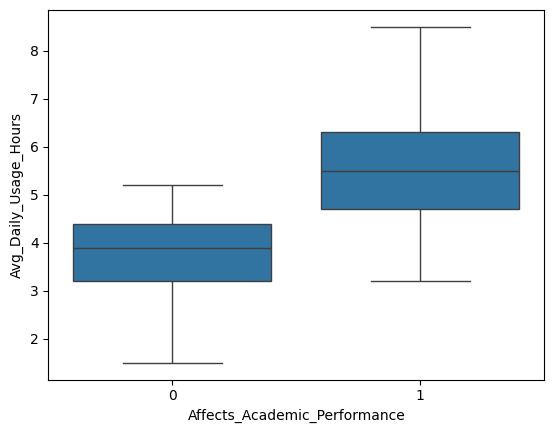

In [12]:
sns.boxplot(
    x='Affects_Academic_Performance',
    y='Avg_Daily_Usage_Hours',
    data=df
)
plt.show()


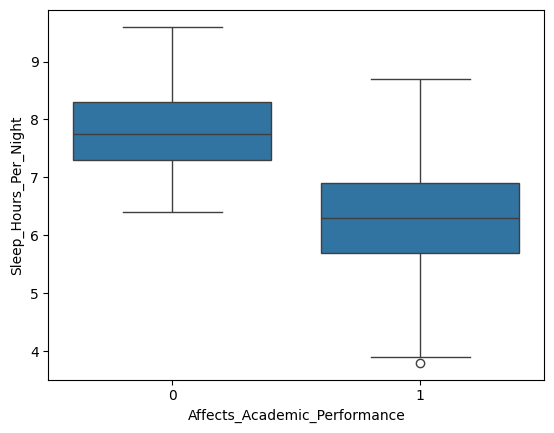

In [13]:
sns.boxplot(
    x='Affects_Academic_Performance',
    y='Sleep_Hours_Per_Night',
    data=df
)
plt.show()


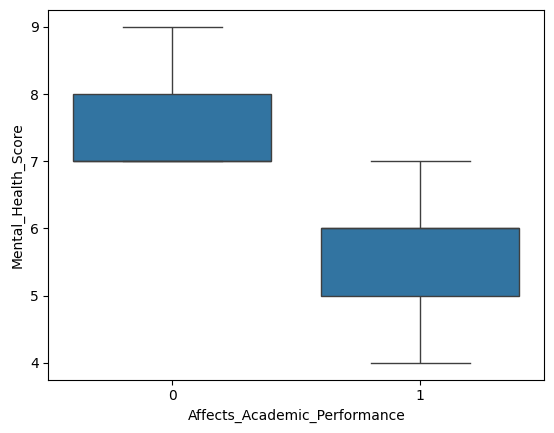

In [14]:
sns.boxplot(
    x='Affects_Academic_Performance',
    y='Mental_Health_Score',
    data=df
)
plt.show()


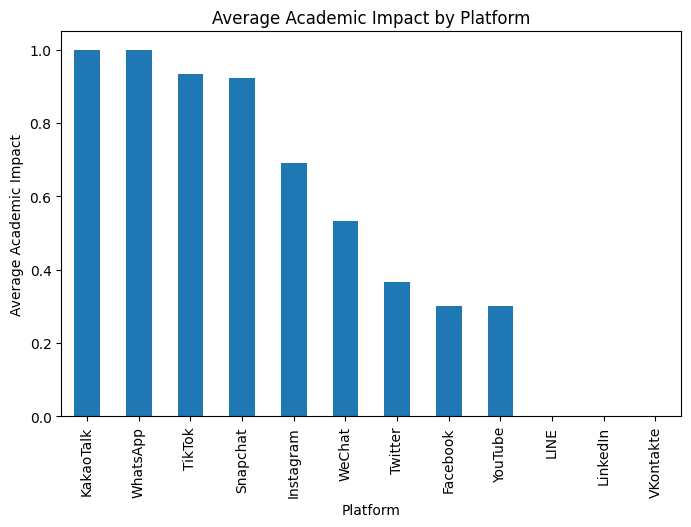

In [15]:
platform_impact = (
    df
    .groupby('Most_Used_Platform')['Affects_Academic_Performance']
    .mean()
    .sort_values(ascending=False)
)

platform_impact
plt.figure(figsize=(8,5))
platform_impact.plot(kind='bar')
plt.ylabel('Average Academic Impact')
plt.xlabel('Platform')
plt.title('Average Academic Impact by Platform')
plt.show()


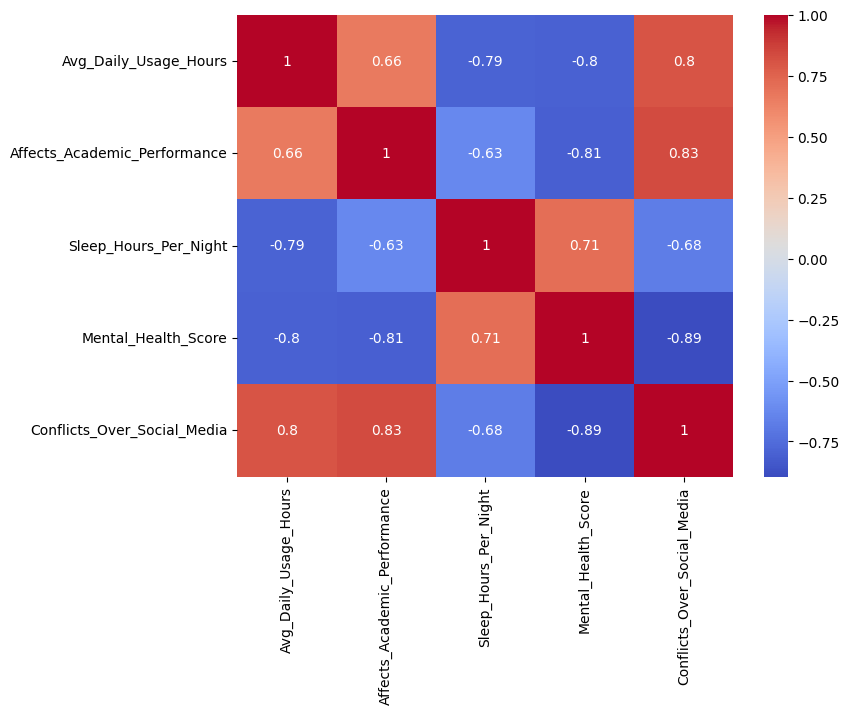

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()


In [17]:
df.groupby('Academic_Level')['Affects_Academic_Performance'].mean()


,Affects_Academic_Performance
Academic_Level,
Graduate,0.612308
High School,0.925926
Undergraduate,0.648725


In [18]:
df.groupby('Most_Used_Platform')['Affects_Academic_Performance'].mean()


,Affects_Academic_Performance
Most_Used_Platform,
Facebook,0.300813
Instagram,0.690763
KakaoTalk,1.000000
LINE,0.000000
LinkedIn,0.000000
Snapchat,0.923077
TikTok,0.935065
Twitter,0.366667
VKontakte,0.000000


In [19]:
df.groupby('Relationship_Status')['Affects_Academic_Performance'].mean()


,Affects_Academic_Performance
Relationship_Status,
Complicated,0.750000
In Relationship,0.539792
Single,0.710938


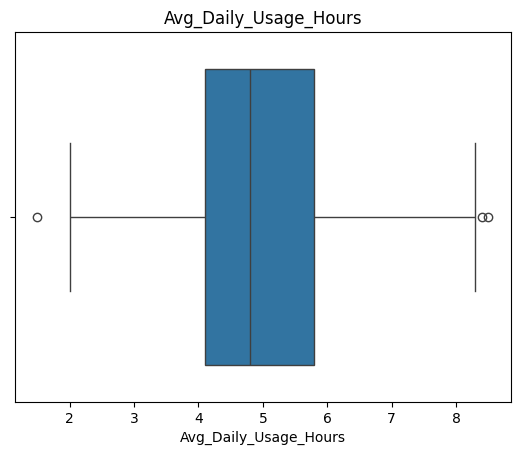

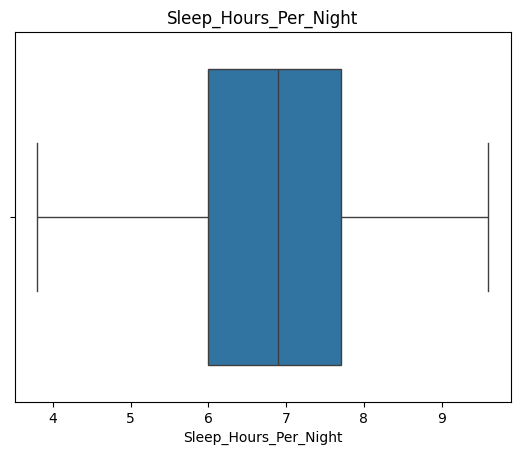

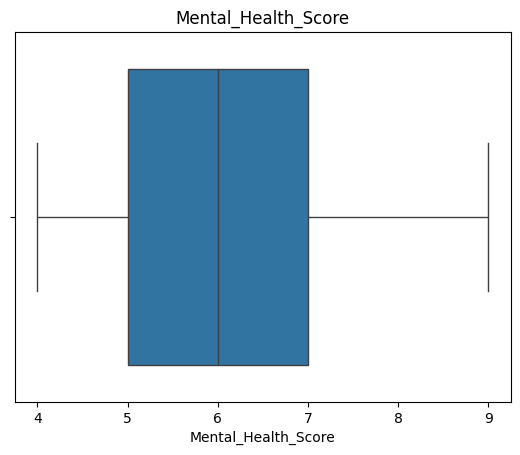

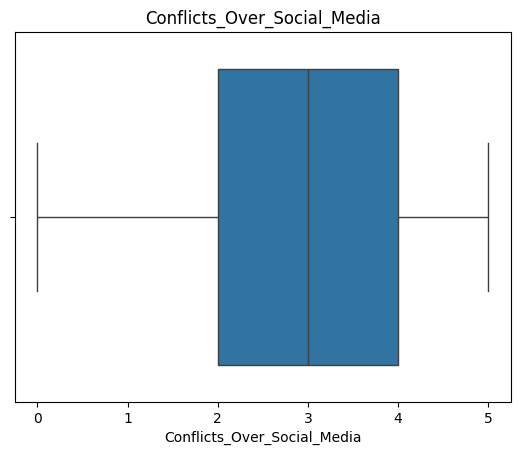

In [20]:
num_cols = [
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
]

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [21]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper


In [22]:
outliers_usage, low, high = detect_outliers_iqr(df, 'Avg_Daily_Usage_Hours')

print("Lower:", low, "Upper:", high)
outliers_usage[['Avg_Daily_Usage_Hours']].head()


Lower: 1.5499999999999994 Upper: 8.35


,Avg_Daily_Usage_Hours
6,1.5
486,8.4
496,8.5


In [23]:
academic_order = {
    'High School': 0,
    'Undergraduate': 1,
    'Graduate': 2
}

df['Academic_Level'] = df['Academic_Level'].map(academic_order)
df = pd.get_dummies(
    df,
    columns=['Most_Used_Platform'],
    drop_first=True
)
df = pd.get_dummies(
    df,
    columns=['Relationship_Status'],
    drop_first=True
)
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Academic_Level                       705 non-null    int64  
 1   Avg_Daily_Usage_Hours                705 non-null    float64
 2   Affects_Academic_Performance         705 non-null    int64  
 3   Sleep_Hours_Per_Night                705 non-null    float64
 4   Mental_Health_Score                  705 non-null    int64  
 5   Conflicts_Over_Social_Media          705 non-null    int64  
 6   Most_Used_Platform_Instagram         705 non-null    bool   
 7   Most_Used_Platform_KakaoTalk         705 non-null    bool   
 8   Most_Used_Platform_LINE              705 non-null    bool   
 9   Most_Used_Platform_LinkedIn          705 non-null    bool   
 10  Most_Used_Platform_Snapchat          705 non-null    bool   
 11  Most_Used_Platform_TikTok       

In [24]:
df.head()


,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Relationship_Status_In Relationship,Relationship_Status_Single
0,1,5.2,1,6.5,6,3,True,False,False,False,False,False,False,False,False,False,False,True,False
1,2,2.1,0,7.5,8,0,False,False,False,False,False,False,True,False,False,False,False,False,True
2,1,6.0,1,5.0,5,4,False,False,False,False,False,True,False,False,False,False,False,False,False
3,0,3.0,0,7.0,7,1,False,False,False,False,False,False,False,False,False,False,True,False,True
4,2,4.5,1,6.0,6,2,False,False,False,False,False,False,False,False,False,False,False,True,False


In [25]:
num_cols = [
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
]


In [26]:

X = df.drop('Affects_Academic_Performance', axis=1)
y = df['Affects_Academic_Performance']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [27]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])



In [28]:
X_train.head()


,Academic_Level,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Relationship_Status_In Relationship,Relationship_Status_Single
171,2,0.320003,-1.036213,-0.234738,1.242338,False,False,False,False,False,True,False,False,False,False,False,True,False
457,2,1.590441,-1.391162,-0.234738,0.190268,False,False,False,False,False,False,False,False,False,True,False,False,True
128,2,0.161198,-0.326314,-1.154130,1.242338,False,False,False,False,False,False,False,False,False,False,False,False,True
109,1,0.002393,-0.947476,-0.234738,0.190268,True,False,False,False,False,False,False,False,False,False,False,False,True
270,1,-0.315216,0.383584,0.684653,-0.861802,True,False,False,False,False,False,False,False,False,False,False,False,True


In [29]:
X_train.describe()


,Academic_Level,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media
count,564.000000,5.640000e+02,5.640000e+02,5.640000e+02,5.640000e+02
mean,1.416667,1.236206e-16,-2.440916e-16,6.614095e-17,8.818793e-17
std,0.567133,1.000888e+00,1.000888e+00,1.000888e+00,1.000888e+00
min,0.000000,-2.697288e+00,-2.722223e+00,-2.073521e+00,-2.965943e+00
25%,1.000000,-6.328259e-01,-7.700010e-01,-1.154130e+00,-8.618023e-01
50%,1.000000,-7.700907e-02,2.863510e-02,-2.347382e-01,1.902680e-01
75%,2.000000,6.376125e-01,7.385338e-01,6.846532e-01,1.242338e+00
max,2.000000,2.860880e+00,2.424543e+00,2.523436e+00,2.294409e+00


In [30]:
y_train.value_counts(normalize=True)


,proportion
Affects_Academic_Performance,
1,0.641844
0,0.358156


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression
[[50  0]
 [ 0 91]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        91

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



In [32]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes
[[45  5]
 [ 9 82]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.87        50
           1       0.94      0.90      0.92        91

    accuracy                           0.90       141
   macro avg       0.89      0.90      0.89       141
weighted avg       0.90      0.90      0.90       141



In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree
[[50  0]
 [ 0 91]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        91

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



In [34]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    class_weight='balanced'
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM
[[50  0]
 [ 0 91]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        91

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN
[[47  3]
 [ 0 91]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        50
           1       0.97      1.00      0.98        91

    accuracy                           0.98       141
   macro avg       0.98      0.97      0.98       141
weighted avg       0.98      0.98      0.98       141



In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("CV Recall scores:", scores)
print("Mean Recall:", scores.mean())


CV Recall scores: [1.         1.         0.97222222 1.         0.98611111]
Mean Recall: 0.9916666666666668


In [37]:
import pandas as pd

results = {
    "Logistic": classification_report(y_test, y_pred_log, output_dict=True)['1']['recall'],
    "Naive Bayes": classification_report(y_test, y_pred_nb, output_dict=True)['1']['recall'],
    "Decision Tree": classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall'],
    "SVM": classification_report(y_test, y_pred_svm, output_dict=True)['1']['recall'],
    "KNN": classification_report(y_test, y_pred_knn, output_dict=True)['1']['recall']
}

pd.DataFrame.from_dict(results, orient='index', columns=['Recall (Class 1)'])


,Recall (Class 1)
Logistic,1.000000
Naive Bayes,0.901099
Decision Tree,1.000000
SVM,1.000000
KNN,1.000000
